In [2]:
# 1. Install the fonts
!sudo apt-get update -y
!sudo apt-get install -y ttf-mscorefonts-installer
!sudo fc-cache -f -v

# 2. Delete the Matplotlib font cache
!rm -rf ~/.cache/matplotlib

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 pytho

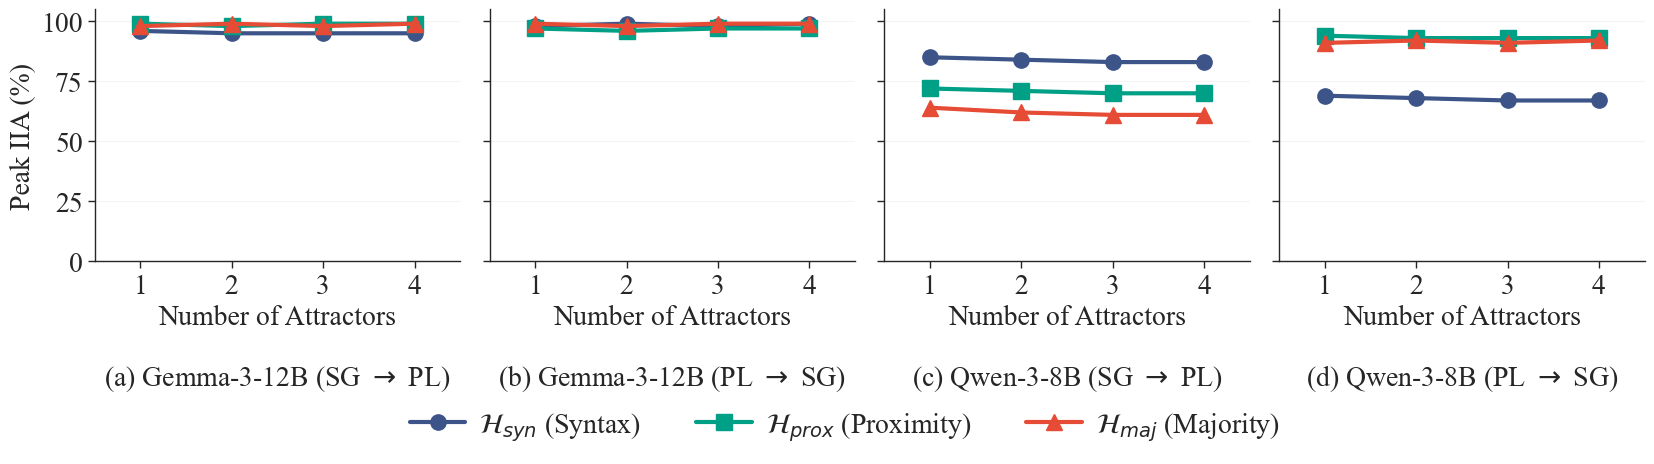

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.lines as mlines

# Apply professional ACL-style aesthetics
sns.set_theme(style="ticks", context="paper")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'serif']
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20

# Define our professional color palette
COLORS = {
    'syn': '#3C5488',
    'prox': '#00A087',
    'maj': '#E64B35'
}

MARKERS = {'syn': 'o', 'prox': 's', 'maj': '^'}

# Create a 1x4 grid to match Figure 1
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

# ---------------------------------------------------------
# DUMMY DATA FOR DEMONSTRATION
# X-axis: Number of Attractors
attractors = [1, 2, 3, 4]

# Y-axis: Peak IIA (extracted from late layers)
# Notice how the data reflects flatline behavior (invariance to depth)
gemma_s2p_peak = {'syn': [96, 95, 95, 95], 'prox': [99, 98, 99, 99], 'maj': [98, 99, 98, 99]}
gemma_p2s_peak = {'syn': [98, 99, 98, 99], 'prox': [97, 96, 97, 97], 'maj': [99, 98, 99, 99]}
qwen_s2p_peak = {'syn': [85, 84, 83, 83], 'prox': [72, 71, 70, 70], 'maj': [64, 62, 61, 61]}
qwen_p2s_peak = {'syn': [69, 68, 67, 67], 'prox': [94, 93, 93, 93], 'maj': [91, 92, 91, 92]}
# ---------------------------------------------------------

data_list = [gemma_s2p_peak, gemma_p2s_peak, qwen_s2p_peak, qwen_p2s_peak]

sub_labels = [
    "(a) Gemma-3-12B (SG $\\rightarrow$ PL)",
    "(b) Gemma-3-12B (PL $\\rightarrow$ SG)",
    "(c) Qwen-3-8B (SG $\\rightarrow$ PL)",
    "(d) Qwen-3-8B (PL $\\rightarrow$ SG)"
]

for i, ax in enumerate(axes):
    data = data_list[i]

    # Plot Peak IIA across attractors
    ax.plot(attractors, data['syn'], marker=MARKERS['syn'], color=COLORS['syn'],
            linewidth=3, markersize=11)
    ax.plot(attractors, data['prox'], marker=MARKERS['prox'], color=COLORS['prox'],
            linewidth=3, markersize=11)
    ax.plot(attractors, data['maj'], marker=MARKERS['maj'], color=COLORS['maj'],
            linewidth=3, markersize=11)

    # Setup axes
    ax.set_ylim(0, 105)
    ax.set_xlim(0.5, 4.5)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlabel(f"Number of Attractors\n\n{sub_labels[i]}")

    if i == 0:
        ax.set_ylabel("Peak IIA (%)")
        ax.set_yticks([0, 25, 50, 75, 100])

    ax.yaxis.grid(True, linestyle='-', alpha=0.2)

# Custom Legend
legend_elements = [
    mlines.Line2D([0], [0], color=COLORS['syn'], marker=MARKERS['syn'], linewidth=3, markersize=11, label=r'$\mathcal{H}_{syn}$ (Syntax)'),
    mlines.Line2D([0], [0], color=COLORS['prox'], marker=MARKERS['prox'], linewidth=3, markersize=11, label=r'$\mathcal{H}_{prox}$ (Proximity)'),
    mlines.Line2D([0], [0], color=COLORS['maj'], marker=MARKERS['maj'], linewidth=3, markersize=11, label=r'$\mathcal{H}_{maj}$ (Majority)')
]

fig.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), frameon=False, handletextpad=0.5, columnspacing=2)

sns.despine()
plt.subplots_adjust(wspace=0.08, bottom=0.25)
plt.savefig("Attractor_Trend_Gemma-Qwen.pdf", dpi=500, bbox_inches='tight')
plt.show()